Pour montrer notre maîtrise de SQL et du nettoyage de données brutes de terrain, nous allons simuler un cas : Nous recevons une table SQL "brute" issue des formulaires de collecte (KoboToolbox ou tableurs) remplis par les enquêteurs sur le terrain. Cette table contient des erreurs volontaires que nous allons devoir corriger avec Python.

Voici le schéma de la base de données que nous allons créer. Elle contient deux tables :

- regions_togo : Table de référence (Régions et chefs-lieux).

- lampadaires_brut : Les données collectées sur le terrain, pleines d'anomalies (valeurs manquantes, doublons, fautes de frappe dans les préfectures, coordonnées aberrantes).

In [2]:
!pip install pandas

In [ ]:
import pandas as pd
import sqlite3
# 1. Connexion à la base de données locale (crée le fichier s'il n'existe pas)
conn = sqlite3.connect("togo_energie.db")
cursor = conn.cursor()

# 2. Création de la table de référence des régions
cursor.execute("""
CREATE TABLE IF NOT EXISTS regions_togo (
    id_region INTEGER PRIMARY KEY AUTOINCREMENT,
    nom_region TEXT NOT NULL,
    chef_lieu TEXT NOT NULL
)
""")

# Insertion des données officielles du Togo
regions_data = [
    ('Savanes', 'Dapaong'),
    ('Kara', 'Kara'),
    ('Centrale', 'Sokodé'),
    ('Plateaux', 'Atakpamé'),
    ('Maritime', 'Tsévié'),
    ('Grand Lomé', 'Lomé')
]
cursor.executemany("INSERT INTO regions_togo (nom_region, chef_lieu) VALUES (?, ?)", regions_data)

# 3. Création de la table brute des lampadaires (avec anomalies de terrain)
cursor.execute("""
CREATE TABLE IF NOT EXISTS lampadaires_brut (
    id_lampadaire TEXT,
    region TEXT,
    prefecture TEXT,
    statut_fonctionnel TEXT,
    puissance_wtts TEXT, -- Volontairement stocké en TEXT avec des erreurs
    date_installation TEXT,
    latitude REAL,
    longitude REAL
)
""")

# Insertion de données "sales" pour tester notre capacité de nettoyage
lampadaires_data = [
    ('LAMP-001', 'Savanes', 'Tône', 'Fonctionnel', '60W', '2024-03-15', 10.8532, 0.2054),
    ('LAMP-002', 'savanes', 'tone', 'En panne', '60 W', '2024-03-16', 10.8610, 0.2105), # Doublon de casse/orthographe
    ('LAMP-003', 'Kara', 'Kozah', 'Fonctionnel', '80W', '2023-11-20', 9.5521, 1.1854),
    ('LAMP-004', 'Kara', 'KOZAH', 'Non Fonctionnel', 'missing', '2023-11-21', 9.5600, 1.1900), # Valeur manquante textuelle
    ('LAMP-005', 'Centrale', 'Tchaoudjo', 'Fonctionnel', '60W', '2025-01-10', 8.9871, 1.1342),
    ('LAMP-005', 'Centrale', 'Tchaoudjo', 'Fonctionnel', '60W', '2025-01-10', 8.9871, 1.1342), # Doublon parfait de ligne
    ('LAMP-006', 'Maritime', 'Zio', 'Fonctionnel', '120W', '2024-05-18', 6.4251, 1.2145),
    ('LAMP-007', 'Maritime', 'Vo', 'En panne', '80W', '2024-06-01', -1.0000, 1.4521), # Latitude aberrante (hors du Togo)
    ('LAMP-008', 'Plateaux', 'Ogou', None, '60W', '2024-07-22', 7.5241, 1.1245), # Statut NULL
]

cursor.executemany("INSERT INTO lampadaires_brut VALUES (?, ?, ?, ?, ?, ?, ?, ?)", lampadaires_data)
conn.commit()

print("Base de données 'togo_energie.db' initialisée avec succès avec les données brutes !")

Base de données 'togo_energie.db' initialisée avec succès avec les données brutes !


Étape 2 : Extraction SQL via Pandas
Maintenant que notre base de données brute est prête, nous allons simuler la première étape du travail d'analyste de données: récupérer les données depuis la base SQL pour les envoyer dans un DataFrame Pandas afin de mener l'audit de qualité.

In [5]:
# Requête SQL pour charger la table brute dans un DataFrame Pandas
query = "SELECT * FROM lampadaires_brut"
df_brut = pd.read_sql_query(query, conn)

# Affichage des premières lignes et des informations de la base
print("--- APPERCU DES DONNEES BRUTES DU TOGO ---")
print(df_brut.head(10))
print("\n--- TYPES DE DONNEES ET VALEURS MANQUANTES ---")
print(df_brut.info())

--- APPERCU DES DONNEES BRUTES DU TOGO ---
  id_lampadaire    region prefecture statut_fonctionnel puissance_wtts  \
0      LAMP-001   Savanes       Tône        Fonctionnel            60W   
1      LAMP-002   savanes       tone           En panne           60 W   
2      LAMP-003      Kara      Kozah        Fonctionnel            80W   
3      LAMP-004      Kara      KOZAH    Non Fonctionnel        missing   
4      LAMP-005  Centrale  Tchaoudjo        Fonctionnel            60W   
5      LAMP-005  Centrale  Tchaoudjo        Fonctionnel            60W   
6      LAMP-006  Maritime        Zio        Fonctionnel           120W   
7      LAMP-007  Maritime         Vo           En panne            80W   
8      LAMP-008  Plateaux       Ogou                NaN            60W   

  date_installation  latitude  longitude  
0        2024-03-15   10.8532     0.2054  
1        2024-03-16   10.8610     0.2105  
2        2023-11-20    9.5521     1.1854  
3        2023-11-21    9.5600     1.1900  
4

Étape 3 : Nettoyage complet des données avec Python (Pandas)
Dans la cellule précédente, nous avons extrait la table brute SQL df_brut. Passons maintenant au nettoyage rigoureux de terrain.

Les défauts identifiés dans notre table brute :

- Doublons : La ligne LAMP-005 est présente deux fois.

- Casse/Texte inconsistant : 'Savanes' et 'savanes', ou 'tone' et 'Tône'.

- Unités parasites dans les valeurs numériques : La colonne puissance_wtts contient des chaînes comme '60W', '60 W' ou 'missing'. On doit la convertir en numérique (Int ou Float).

- Anomalies de coordonnées géographiques : Le Togo se situe grossièrement entre les latitudes 6.0° N et 11.2° N et les longitudes 0.0° et 2.0° E. Le lampadaire LAMP-007 a une latitude de -1.0000 (il est dans l'océan Atlantique).

-Valeurs manquantes (NaN) : Le statut du LAMP-008 est manquant.

In [6]:
import numpy as np

# Copie de sécurité pour travailler proprement
df_clean = df_brut.copy()

print("--- DEBUT DU NETTOYAGE DES DONNEES ---")

# 1. Suppression des doublons stricts
nb_doublons = df_clean.duplicated(subset=['id_lampadaire']).sum()
df_clean = df_clean.drop_duplicates(subset=['id_lampadaire'], keep='first')
print(f"1. {nb_doublons} doublon(s) supprimé(s).")

# 2. Harmonisation du texte (Majuscule en début de mot, suppression des espaces inutiles)
df_clean['region'] = df_clean['region'].str.strip().str.title()
df_clean['prefecture'] = df_clean['prefecture'].str.strip().str.title()
# Correction spécifique pour l'accentuation de Tône (courant avec les bases de données)
df_clean['prefecture'] = df_clean['prefecture'].replace({'Tone': 'Tône'})
print("2. Orthographe des régions et préfectures harmonisée.")

# 3. Nettoyage de la colonne Puissance (Extraction du nombre)
# On retire les lettres 'W', les espaces, et on remplace 'missing' par NaN
df_clean['puissance_wtts'] = df_clean['puissance_wtts'].astype(str).str.replace('W', '', case=False).str.strip()
df_clean['puissance_wtts'] = pd.to_numeric(df_clean['puissance_wtts'], errors='coerce')
# Remplacement des valeurs manquantes par la médiane des puissances (ex: 60W)
mediane_puissance = df_clean['puissance_wtts'].median()
df_clean['puissance_wtts'] = df_clean['puissance_wtts'].fillna(mediane_puissance).astype(int)
print(f"3. Colonne Puissance nettoyée et convertie en entiers (Valeurs invalides remplacées par la médiane : {mediane_puissance}W).")

# 4. Gestion des valeurs manquantes pour le Statut Fonctionnel
# Pour un inventaire de sécurité, on classe les inconnus en "À vérifier"
df_clean['statut_fonctionnel'] = df_clean['statut_fonctionnel'].fillna('À vérifier')
print("4. Valeurs manquantes du statut fonctionnel catégorisées comme 'À vérifier'.")

# 5. Filtrage des anomalies géographiques (Validation des coordonnées du Togo)
# Définition des bornes géographiques réalistes du Togo
lat_min, lat_max = 6.0, 11.2
lon_min, lon_max = 0.0, 2.0

# On identifie les lignes hors bornes
hors_bornes = df_clean[
    (df_clean['latitude'] < lat_min) | (df_clean['latitude'] > lat_max) |
    (df_clean['longitude'] < lon_min) | (df_clean['longitude'] > lon_max)
]

# Option professionnelle : au lieu de supprimer, on remplace par NaN ou on isole pour l'équipe terrain
# Ici, nous allons les flagger pour contrôle qualité
print(f"5. Alerte Contrôle Qualité : {len(hors_bornes)} lampadaire(s) localisé(s) hors des frontières du Togo (ex: LAMP-007).")
# Pour la suite des analyses statistiques, on filtre les coordonnées valides
df_analyses = df_clean[
    (df_clean['latitude'] >= lat_min) & (df_clean['latitude'] <= lat_max)
].copy()

print("\n--- APPERCU DU DATAFRAME PROPRE ET NETTOYE ---")
print(df_analyses)

--- DEBUT DU NETTOYAGE DES DONNEES ---
1. 1 doublon(s) supprimé(s).
2. Orthographe des régions et préfectures harmonisée.
3. Colonne Puissance nettoyée et convertie en entiers (Valeurs invalides remplacées par la médiane : 60.0W).
4. Valeurs manquantes du statut fonctionnel catégorisées comme 'À vérifier'.
5. Alerte Contrôle Qualité : 1 lampadaire(s) localisé(s) hors des frontières du Togo (ex: LAMP-007).

--- APPERCU DU DATAFRAME PROPRE ET NETTOYE ---
  id_lampadaire    region prefecture statut_fonctionnel  puissance_wtts  \
0      LAMP-001   Savanes       Tône        Fonctionnel              60   
1      LAMP-002   Savanes       Tône           En panne              60   
2      LAMP-003      Kara      Kozah        Fonctionnel              80   
3      LAMP-004      Kara      Kozah    Non Fonctionnel              60   
4      LAMP-005  Centrale  Tchaoudjo        Fonctionnel              60   
6      LAMP-006  Maritime        Zio        Fonctionnel             120   
8      LAMP-008  P

Etape 4: Les premières statistiques descriptives

Maintenant que nos données sont parfaitement propres, nous allons passer aux statistiques descriptives et agrégations. C'est l'étape où la donnée brute prend tout son sens pour un décideur : nous allons calculer le taux de panne et la puissance totale installée par région et préfecture du Togo.

In [8]:
print("--- CALCUL DES STATISTIQUES DESCRIPTIVES (PROJET LAMPADAIRES) ---")

# 1. Vue d'ensemble globale du parc de lampadaires
total_lampadaires = len(df_analyses)  # Corrigé ici (t minuscule)
puissance_totale = df_analyses['puissance_wtts'].sum()  # Corrigé ici (p minuscule)
taux_panne_global = (df_analyses['statut_fonctionnel'] == 'En panne').mean() * 100  # Corrigé ici (t minuscule)

print(f"Nombre total de lampadaires analysés : {total_lampadaires}")
print(f"Puissance énergétique totale déployée : {puissance_totale} Watts")
print(f"Taux de panne global au niveau national : {taux_panne_global:.1f}%\n")

# 2. Agrégation par Région et Préfecture
stats_territoire = df_analyses.groupby(['region', 'prefecture']).agg(
    total_lampadaires=('id_lampadaire', 'count'),
    puissance_moyenne_w=('puissance_wtts', 'mean'),
    en_panne=('statut_fonctionnel', lambda x: (x == 'En panne').sum())
).reset_index()

# 3. Calcul du taux de panne par zone locale
stats_territoire['taux_panne_%'] = (stats_territoire['en_panne'] / stats_territoire['total_lampadaires']) * 100

print("--- TABLEAU DE SYNTHESE DESTINE AUX CHEFS DE PROJET ---")
print(stats_territoire)

--- CALCUL DES STATISTIQUES DESCRIPTIVES (PROJET LAMPADAIRES) ---
Nombre total de lampadaires analysés : 7
Puissance énergétique totale déployée : 500 Watts
Taux de panne global au niveau national : 14.3%

--- TABLEAU DE SYNTHESE DESTINE AUX CHEFS DE PROJET ---
     region prefecture  total_lampadaires  puissance_moyenne_w  en_panne  \
0  Centrale  Tchaoudjo                  1                 60.0         0   
1      Kara      Kozah                  2                 70.0         0   
2  Maritime        Zio                  1                120.0         0   
3  Plateaux       Ogou                  1                 60.0         0   
4   Savanes       Tône                  2                 60.0         1   

   taux_panne_%  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4          50.0  


Etapes suivantes: 

Sauvegarde dans SQL : Transférer nos données nettoyées et nos statistiques agrégées dans de nouvelles tables propres au sein de notre base togo_energie.db.

Visualisation graphique : Générer un graphique percutant avec Matplotlib et Seaborn pour représenter visuellement le taux de pannes par préfecture.

Etape 5: Sauvegarde des résultats dans la base SQL 

Exécutons ce code dans une nouvelle cellule pour archiver les données propres et la synthèse des indicateurs (KPI) :


In [9]:
print("--- SAUVEGARDE DES DONNEES PROPRES EN BASE SQL ---")

# 1. Sauvegarde de la table des lampadaires nettoyés
df_analyses.to_sql("lampadaires_propres", conn, if_exists="replace", index=False)

# 2. Sauvegarde du tableau de synthèse par région/préfecture
stats_territoire.to_sql("kpi_pannes_territoire", conn, if_exists="replace", index=False)

print("Tables 'lampadaires_propres' et 'kpi_pannes_territoire' sauvegardées avec succès !")

# Petite vérification rapide en fermant proprement la connexion plus tard
conn.commit()

--- SAUVEGARDE DES DONNEES PROPRES EN BASE SQL ---
Tables 'lampadaires_propres' et 'kpi_pannes_territoire' sauvegardées avec succès !


Etape 6: Création du graphique avec Matplotlib et Seaborn 

Nous allons créer un diagramme à barres horizontal. C’est le format idéal pour comparer des zones géographiques (préfectures) sans que les noms ne se chevauchent sur l'axe.

In [ ]:
!pip install matplotlib
!pip install seaborn

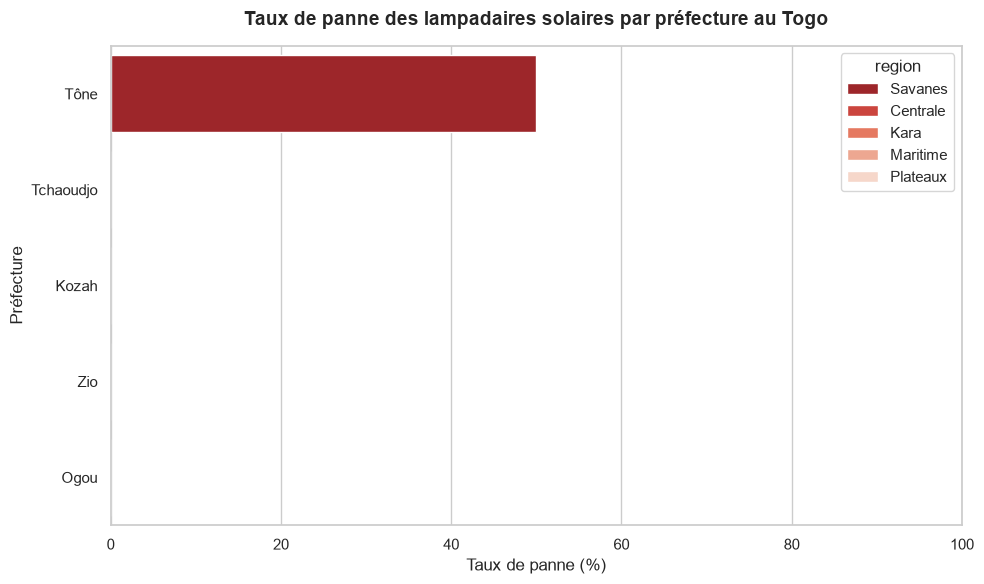

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style graphique
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Création du graphique à barres horizontales
# On trie les préfectures par taux de panne pour une meilleure lecture
stats_triees = stats_territoire.sort_values(by="taux_panne_%", ascending=False)

sns.barplot(
    x="taux_panne_%", 
    y="prefecture", 
    hue="region", 
    data=stats_triees, 
    palette="Reds_r"
)

# Personnalisation des titres et axes pour un rendu professionnel
plt.title("Taux de panne des lampadaires solaires par préfecture au Togo", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Taux de panne (%)", fontsize=12)
plt.ylabel("Préfecture", fontsize=12)
plt.xlim(0, 100) # Le taux va de 0 à 100%

# Ajustement des marges pour éviter les coupures du texte
plt.tight_layout()

# Affichage du graphique
plt.show()